# Imports

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.neighbors import KernelDensity
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# EDA and Preprocessing

In [ ]:
df = pd.read_csv('cybersecurity_intrusion_data.csv')
df['encryption_used'] = df['encryption_used'].fillna('None')
print(df['attack_detected'].value_counts())

# Turning categorical data into one-hot vectors.
categorical = ['protocol_type', 'encryption_used', 'browser_type']
for col in categorical:
    values = df[col].unique()
    #print(df[col].value_counts())
    print()
    for value in values:
        df[value] = df[col].apply(lambda x: 1 if x == value else 0)

df.drop(categorical, axis=1, inplace=True)
df.drop('session_id', axis=1, inplace=True)

df

attack_detected
0    5273
1    4264
Name: count, dtype: int64





,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected,TCP,UDP,ICMP,DES,AES,None,Edge,Firefox,Chrome,Unknown,Safari
0,599,4,492.983263,0.606818,1,0,1,1,0,0,1,0,0,1,0,0,0,0
1,472,3,1557.996461,0.301569,0,0,0,1,0,0,1,0,0,0,1,0,0,0
2,629,3,75.044262,0.739164,2,0,1,1,0,0,1,0,0,0,0,1,0,0
3,804,4,601.248835,0.123267,0,0,1,0,1,0,1,0,0,0,0,0,1,0
4,453,5,532.540888,0.054874,1,0,0,1,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9532,194,3,226.049889,0.517737,3,0,1,0,0,1,0,1,0,0,0,1,0,0
9533,380,3,182.848475,0.408485,0,0,0,1,0,0,0,0,1,0,0,1,0,0
9534,664,5,35.170248,0.359200,1,0,0,1,0,0,0,1,0,0,1,0,0,0
9535,406,4,86.664703,0.537417,1,1,0,1,0,0,0,1,0,0,0,1,0,0


In [ ]:
RANDOM_STATE = 8
train_set, test_set = train_test_split(df, random_state=RANDOM_STATE)

def scale_features(train_set, test_set):
    quantitative = ['network_packet_size', 'login_attempts', 'session_duration',
                    'ip_reputation_score', 'failed_logins']

    scaler = StandardScaler()
    scaler.fit(train_set[quantitative])
    train_set[quantitative] = scaler.transform(train_set[quantitative])
    test_set[quantitative] = scaler.transform(test_set[quantitative])

def evaluate(predictions, labels):
    print("\tAccuracy: ", accuracy_score(labels, predictions))
    print("\tPrecision: ", precision_score(labels, predictions))
    print("\tRecall: ", recall_score(labels, predictions))
    print("\tF1: ", f1_score(labels, predictions))

kf = KFold()

# Predictions (Supervised)

To evaluate each model, we perform the same steps.

1. Generate folds as per K-Folds cross-validation.
2. Preprocess the features in the training and validation sets of each fold according to its training set.
3. Fit the model on the training set, and evaluate it on the validation set, repeating this for each fold.

## No Dimensionality Reduction

### Kernel Density

In [ ]:
for i, (train_indices, valid_indices) in enumerate(kf.split(train_set)):
    train, valid = train_set.iloc[train_indices].copy(), train_set.iloc[valid_indices].copy()
    scale_features(train, valid)

    # Split into the two classes.
    train_attack = train[train['attack_detected']==1].drop('attack_detected', axis=1)
    train_no_attack = train[train['attack_detected']==0].drop('attack_detected', axis=1)

    kde_attack = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(train_attack)
    kde_no_attack = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(train_no_attack)

    valid_features = valid.drop('attack_detected', axis=1)

    valid_log_density_attack = kde_attack.score_samples(valid_features)
    valid_log_density_no_attack = kde_no_attack.score_samples(valid_features)

    n = len(valid_log_density_attack)
    assert n == len(valid_log_density_no_attack)

    valid["Predictions"] = [1 if valid_log_density_attack[j] > valid_log_density_no_attack[j] else 0 for j in range(n)]
    print(f"Fold {i}:")
    evaluate(valid["Predictions"], valid["attack_detected"])

Fold 0:
	Accuracy:  0.8141160027952481
	Precision:  0.8619402985074627
	Recall:  0.7064220183486238
	F1:  0.7764705882352941
Fold 1:
	Accuracy:  0.8092243186582809
	Precision:  0.8595825426944972
	Recall:  0.6947852760736196
	F1:  0.7684478371501272
Fold 2:
	Accuracy:  0.8111888111888111
	Precision:  0.8635477582846004
	Recall:  0.6889580093312597
	F1:  0.7664359861591695
Fold 3:
	Accuracy:  0.8125874125874126
	Precision:  0.8317214700193424
	Recall:  0.7037643207855974
	F1:  0.7624113475177305
Fold 4:
	Accuracy:  0.8041958041958042
	Precision:  0.8620689655172413
	Recall:  0.6671899529042387
	F1:  0.7522123893805309


### Neural Network

In [ ]:
for i, (train_indices, valid_indices) in enumerate(kf.split(train_set)):
    train, valid = train_set.iloc[train_indices].copy(), train_set.iloc[valid_indices].copy()
    scale_features(train, valid)

    train_features = train.drop('attack_detected', axis=1)
    valid_features = valid.drop('attack_detected', axis=1)
    train_labels = train['attack_detected']
    valid_labels = valid['attack_detected']

    clf = MLPClassifier(max_iter=1000, random_state=RANDOM_STATE).fit(train_features, train_labels)
    predictions = clf.predict(valid_features)

    print(f"Fold {i}:")
    evaluate(predictions, valid_labels)


Fold 0:
	Accuracy:  0.8756114605171209
	Precision:  0.9375
	Recall:  0.7798165137614679
	F1:  0.8514190317195326
Fold 1:
	Accuracy:  0.8735150244584207
	Precision:  0.9243243243243243
	Recall:  0.7868098159509203
	F1:  0.8500414250207126
Fold 2:
	Accuracy:  0.8692307692307693
	Precision:  0.9269662921348315
	Recall:  0.7698289269051322
	F1:  0.8411214953271028
Fold 3:
	Accuracy:  0.8811188811188811
	Precision:  0.9281553398058252
	Recall:  0.7823240589198036
	F1:  0.8490230905861457
Fold 4:
	Accuracy:  0.8685314685314686
	Precision:  0.9243856332703214
	Recall:  0.7676609105180534
	F1:  0.8387650085763293


We see that we have good results here for both models; next we want to check if we get similarly strong results even after reducing the dimensionality of the data.

## LDA

We would now like to repeat our analysis but using dimensionality reduction. Our dimensionality reduction algorithm of choice will be LDA; it will try to separate the classes, which should help the algorithms differentiate them.

In [ ]:
for i, (train_indices, valid_indices) in enumerate(kf.split(train_set)):
    train, valid = train_set.iloc[train_indices].copy(), train_set.iloc[valid_indices].copy()
    scale_features(train, valid)

    train_features = train.drop('attack_detected', axis=1)
    valid_features = valid.drop('attack_detected', axis=1)
    train_labels = train['attack_detected']
    valid_labels = valid['attack_detected']

    lda = LinearDiscriminantAnalysis().fit(train_features, train_labels)
    train_features_lda = lda.transform(train_features)
    valid_features_lda = lda.transform(valid_features)

    # Split into the two classes.
    train_attack_lda = train_features_lda[train_labels==1]
    train_no_attack_lda = train_features_lda[train_labels==0]

    kde_attack = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(train_attack_lda)
    kde_no_attack = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(train_no_attack_lda)

    valid_log_density_attack = kde_attack.score_samples(valid_features_lda)
    valid_log_density_no_attack = kde_no_attack.score_samples(valid_features_lda)

    n = len(valid_log_density_attack)
    assert n == len(valid_log_density_no_attack)

    valid["Predictions"] = [1 if valid_log_density_attack[j] > valid_log_density_no_attack[j] else 0 for j in range(n)]
    print(f"Fold {i}:")
    evaluate(valid["Predictions"], valid["attack_detected"])

Fold 0:
	Accuracy:  0.7470300489168413
	Precision:  0.738562091503268
	Recall:  0.691131498470948
	F1:  0.7140600315955766
Fold 1:
	Accuracy:  0.7372466806429071
	Precision:  0.7254901960784313
	Recall:  0.6809815950920245
	F1:  0.7025316455696202
Fold 2:
	Accuracy:  0.7447552447552448
	Precision:  0.7316666666666667
	Recall:  0.6827371695178849
	F1:  0.7063555913113435
Fold 3:
	Accuracy:  0.7391608391608392
	Precision:  0.71875
	Recall:  0.6399345335515548
	F1:  0.677056277056277
Fold 4:
	Accuracy:  0.7398601398601399
	Precision:  0.7234401349072512
	Recall:  0.673469387755102
	F1:  0.697560975609756


In [ ]:
for i, (train_indices, valid_indices) in enumerate(kf.split(train_set)):
    train, valid = train_set.iloc[train_indices].copy(), train_set.iloc[valid_indices].copy()
    scale_features(train, valid)

    train_features = train.drop('attack_detected', axis=1)
    valid_features = valid.drop('attack_detected', axis=1)
    train_labels = train['attack_detected']
    valid_labels = valid['attack_detected']

    lda = LinearDiscriminantAnalysis().fit(train_features, train_labels)
    train_features_lda = lda.transform(train_features)
    valid_features_lda = lda.transform(valid_features)

    clf = MLPClassifier(max_iter=1000, random_state=RANDOM_STATE).fit(train_features_lda, train_labels)
    predictions = clf.predict(valid_features_lda)

    print(f"Fold {i}:")
    evaluate(predictions, valid_labels)

Fold 0:
	Accuracy:  0.7540181691125087
	Precision:  0.7755474452554745
	Recall:  0.6498470948012233
	F1:  0.7071547420965059
Fold 1:
	Accuracy:  0.7414395527603075
	Precision:  0.7554347826086957
	Recall:  0.6395705521472392
	F1:  0.6926910299003323
Fold 2:
	Accuracy:  0.7433566433566433
	Precision:  0.7584269662921348
	Recall:  0.6298600311041991
	F1:  0.6881903143585386
Fold 3:
	Accuracy:  0.7377622377622378
	Precision:  0.7448132780082988
	Recall:  0.5875613747954174
	F1:  0.656907593778591
Fold 4:
	Accuracy:  0.7440559440559441
	Precision:  0.7542213883677298
	Recall:  0.631083202511774
	F1:  0.6871794871794872


## PCA

Since we have two classes, we are forced to project to one dimension for LDA. Here, we try PCA to try to keep some dimensionality.

### Kernel Density

In [ ]:
for i, (train_indices, valid_indices) in enumerate(kf.split(train_set)):
    train, valid = train_set.iloc[train_indices].copy(), train_set.iloc[valid_indices].copy()
    scale_features(train, valid)

    train_features = train.drop('attack_detected', axis=1)
    valid_features = valid.drop('attack_detected', axis=1)
    train_labels = train['attack_detected']
    valid_labels = valid['attack_detected']

    pca = PCA(n_components=5).fit(train_features)
    train_features_pca = pca.transform(train_features)
    valid_features_pca = pca.transform(valid_features)

    # Split into the two classes.
    train_attack_pca = train_features_pca[train_labels==1]
    train_no_attack_pca = train_features_pca[train_labels==0]

    kde_attack = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(train_attack_pca)
    kde_no_attack = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(train_no_attack_pca)

    valid_log_density_attack = kde_attack.score_samples(valid_features_pca)
    valid_log_density_no_attack = kde_no_attack.score_samples(valid_features_pca)

    n = len(valid_log_density_attack)
    assert n == len(valid_log_density_no_attack)

    valid["Predictions"] = [1 if valid_log_density_attack[j] > valid_log_density_no_attack[j] else 0 for j in range(n)]
    print(f"Fold {i}:")
    evaluate(valid["Predictions"], valid["attack_detected"])

Fold 0:
	Accuracy:  0.8588399720475192
	Precision:  0.9631147540983607
	Recall:  0.7186544342507645
	F1:  0.8231173380035026
Fold 1:
	Accuracy:  0.8539482879105521
	Precision:  0.9643605870020965
	Recall:  0.7055214723926381
	F1:  0.8148804251550045
Fold 2:
	Accuracy:  0.8545454545454545
	Precision:  0.967741935483871
	Recall:  0.6998444790046656
	F1:  0.8122743682310469
Fold 3:
	Accuracy:  0.8727272727272727
	Precision:  0.9612903225806452
	Recall:  0.7315875613747954
	F1:  0.8308550185873605
Fold 4:
	Accuracy:  0.8468531468531468
	Precision:  0.9523809523809523
	Recall:  0.6907378335949764
	F1:  0.8007279344858963


### Neural Network

In [ ]:
for i, (train_indices, valid_indices) in enumerate(kf.split(train_set)):
    train, valid = train_set.iloc[train_indices].copy(), train_set.iloc[valid_indices].copy()
    scale_features(train, valid)

    train_features = train.drop('attack_detected', axis=1)
    valid_features = valid.drop('attack_detected', axis=1)
    train_labels = train['attack_detected']
    valid_labels = valid['attack_detected']

    pca = PCA(n_components=5).fit(train_features)
    train_features_pca = pca.transform(train_features)
    valid_features_pca = pca.transform(valid_features)

    clf = MLPClassifier(max_iter=1000, random_state=RANDOM_STATE).fit(train_features_pca, train_labels)
    predictions = clf.predict(valid_features_pca)

    print(f"Fold {i}:")
    evaluate(predictions, valid_labels)

Fold 0:
	Accuracy:  0.8665269042627534
	Precision:  0.9873684210526316
	Recall:  0.7171253822629969
	F1:  0.8308237378210807
Fold 1:
	Accuracy:  0.870020964360587
	Precision:  0.9957446808510638
	Recall:  0.7177914110429447
	F1:  0.8342245989304813
Fold 2:
	Accuracy:  0.8664335664335664
	Precision:  0.9891774891774892
	Recall:  0.7107309486780715
	F1:  0.8271493212669683
Fold 3:
	Accuracy:  0.8783216783216783
	Precision:  0.9802197802197802
	Recall:  0.7299509001636661
	F1:  0.8367729831144465
Fold 4:
	Accuracy:  0.8622377622377623
	Precision:  0.9824561403508771
	Recall:  0.7032967032967034
	F1:  0.8197621225983531


# Unsupervised Learning

What we want is to train a model on only no attack instances and identify potential attacks. To do this, we will use K-means clustering. We will consider a data point anomalous if it is sufficiently far away from its respective mean and guess that it is an attack.

Our first goal is to identify a suitable value for the number of clusters.

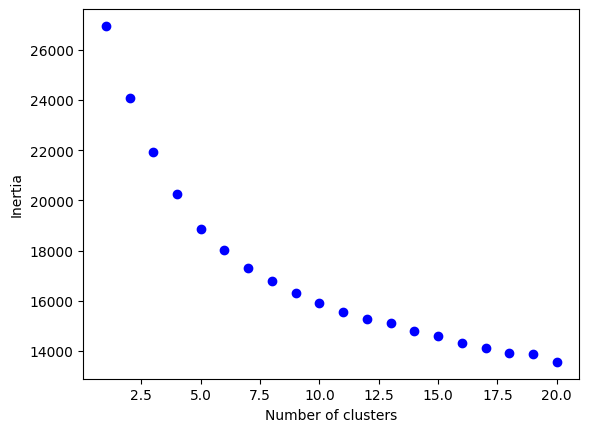

In [ ]:
# We only want to train the model on instances of no attack.
# We ignore any attacks in our training data.
train_no_attack = train_set[train_set['attack_detected']==0].drop('attack_detected', axis=1)
test_features = test_set.drop('attack_detected', axis=1)
scale_features(train_no_attack, test_features)

K = 20
inertias = np.empty(K)
for k in range(K):
    inertias[k] = KMeans(k+1).fit(train_no_attack).inertia_

plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.plot(range(1,K+1), inertias, 'bo')
plt.show()

$k=3$ seems to be a logical option here. Next, we'd like to see about how much each point differs from its class mean.

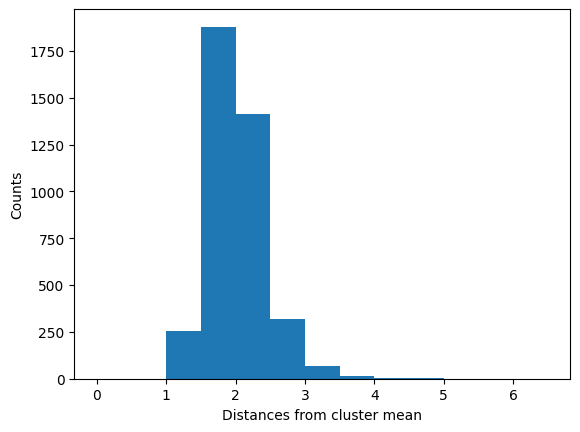

In [ ]:
kmeans = KMeans(8, random_state=RANDOM_STATE, n_init='auto').fit(train_no_attack)

n = len(train_no_attack)
distances = np.empty(n)

for i, point in enumerate(train_no_attack.values):
    distances[i] = np.linalg.norm(point - kmeans.cluster_centers_[kmeans.labels_[i]])

plt.xlabel('Distances from cluster mean')
plt.ylabel('Counts')
plt.hist(distances, bins=np.arange(0, 7, 0.5))
plt.show()

In [ ]:
for p in range(60, 100, 10):
    d = np.percentile(distances, p)
    print(f"p = {p}, d = {d}")

    test_predicted_clusters = kmeans.predict(test_features)
    test_distances = np.empty(len(test_set))
    predictions = np.empty(len(test_set))
    for i, point in enumerate(test_features.values):
        test_distances[i] = np.linalg.norm(point - kmeans.cluster_centers_[test_predicted_clusters[i]])
        predictions[i] = 1 if test_distances[i] > d else 0
    evaluate(predictions, test_set['attack_detected'])

p = 60, d = 2.057662212020806
	Accuracy:  0.6846960167714885
	Precision:  0.6079506511309116
	Recall:  0.831302717900656
	F1:  0.7022961203483769
p = 70, d = 2.169868773203536
	Accuracy:  0.7337526205450734
	Precision:  0.6692789968652038
	Recall:  0.8003748828491096
	F1:  0.7289799402475459
p = 80, d = 2.300763249997628
	Accuracy:  0.7685534591194969
	Precision:  0.7404295051353875
	Recall:  0.7432052483598875
	F1:  0.7418147801683816
p = 90, d = 2.5111325931991515
	Accuracy:  0.7790356394129979
	Precision:  0.8260869565217391
	Recall:  0.6410496719775071
	F1:  0.7218997361477573


# Conclusion


At this point, we would like to train the supervised models on the full training set and use the test set.

In [ ]:
scale_features(train_set, test_set)

train_features = train_set.drop('attack_detected', axis=1)
test_features = test_set.drop('attack_detected', axis=1)
train_labels = train_set['attack_detected']
test_labels = test_set['attack_detected']

## No Dimensionality Reduction

### Kernel Density

In [ ]:
# KDE, no LDA

# Split into the two classes
train_attack = train_set[train_set['attack_detected']==1].drop('attack_detected', axis=1)
train_no_attack = train_set[train_set['attack_detected']==0].drop('attack_detected', axis=1)

kde_attack = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(train_attack)
kde_no_attack = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(train_no_attack)

test_log_density_attack = kde_attack.score_samples(test_features)
test_log_density_no_attack = kde_no_attack.score_samples(test_features)

n = len(test_log_density_attack)
assert n == len(test_log_density_no_attack)

KDE_predictions = [1 if test_log_density_attack[j] > test_log_density_no_attack[j] else 0 for j in range(n)]
evaluate(KDE_predictions, test_set['attack_detected'])

	Accuracy:  0.8268343815513627
	Precision:  0.8682432432432432
	Recall:  0.7225866916588566
	F1:  0.7887468030690538


### Neural Network

In [ ]:
clf = MLPClassifier(max_iter=1000, random_state=RANDOM_STATE).fit(train_features, train_labels)
NN_predictions = clf.predict(test_features)
evaluate(NN_predictions, test_set['attack_detected'])

	Accuracy:  0.8784067085953878
	Precision:  0.9460390355912744
	Recall:  0.7722586691658857
	F1:  0.8503611971104231


## LDA

In [ ]:
lda = LinearDiscriminantAnalysis().fit(train_features, train_labels)
train_features_lda = lda.transform(train_features)
test_features_lda = lda.transform(test_features)

## Kernel Density

In [ ]:
train_attack_lda = train_features_lda[train_labels==1]
train_no_attack_lda = train_features_lda[train_labels==0]

kde_attack_lda = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(train_attack_lda)
kde_no_attack_lda = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(train_no_attack_lda)

test_log_density_attack_lda = kde_attack_lda.score_samples(test_features_lda)
test_log_density_no_attack_lda = kde_no_attack_lda.score_samples(test_features_lda)

n = len(test_log_density_attack_lda)
assert n == len(test_log_density_no_attack_lda)

KDE_predictions_lda = [1 if test_log_density_attack_lda[j] > test_log_density_no_attack_lda[j] else 0 for j in range(n)]
evaluate(KDE_predictions_lda, test_set['attack_detected'])

	Accuracy:  0.730817610062893
	Precision:  0.7110228401191658
	Recall:  0.6710402999062793
	F1:  0.6904532304725168


### Neural Network

In [ ]:
clf_lda = MLPClassifier(max_iter=1000, random_state=RANDOM_STATE).fit(train_features_lda, train_labels)
NN_predictions_lda = clf_lda.predict(test_features_lda)
evaluate(NN_predictions_lda, test_set['attack_detected'])

	Accuracy:  0.7433962264150943
	Precision:  0.7576443941109853
	Recall:  0.626991565135895
	F1:  0.6861538461538461


## PCA

In [ ]:
pca = PCA(n_components=5).fit(train_features)
train_features_pca = pca.transform(train_features)
test_features_pca = pca.transform(test_features)

### Kernel Density

In [ ]:
train_attack_pca = train_features_pca[train_labels==1]
train_no_attack_pca = train_features_pca[train_labels==0]

kde_attack_pca = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(train_attack_pca)
kde_no_attack_pca = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(train_no_attack_pca)

test_log_density_attack_pca = kde_attack_pca.score_samples(test_features_pca)
test_log_density_no_attack_pca = kde_no_attack_pca.score_samples(test_features_pca)

n = len(test_log_density_attack_pca)
assert n == len(test_log_density_no_attack_pca)

KDE_predictions_pca = [1 if test_log_density_attack_pca[j] > test_log_density_no_attack_pca[j] else 0 for j in range(n)]
evaluate(KDE_predictions_pca, test_set['attack_detected'])

	Accuracy:  0.8557651991614256
	Precision:  0.9605095541401274
	Recall:  0.7066541705716963
	F1:  0.8142548596112311


### Neural Network

In [ ]:
clf_pca = MLPClassifier(max_iter=1000, random_state=RANDOM_STATE).fit(train_features_pca, train_labels)
NN_predictions_pca = clf_pca.predict(test_features_pca)
evaluate(NN_predictions_pca, test_set['attack_detected'])

	Accuracy:  0.8666666666666667
	Precision:  0.9882659713168188
	Recall:  0.7104029990627929
	F1:  0.826608505997819
